In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

from sklearn.model_selection import cross_val_score

In [2]:
df = pd.read_csv("Titanic-Dataset.csv")

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

In [5]:
df = df.drop(['PassengerId','Name','Ticket','Cabin'],axis=1)

In [6]:
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

In [7]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


In [8]:
X = df.drop('Survived',axis=1)
y = df['Survived']

In [9]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [30]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Logistic Regression

Logistic Regression is a supervised machine learning algorithm used for classification problems. It predicts the probability that an instance belongs to a particular class using the logistic (sigmoid) function. It is widely used for binary classification tasks such as predicting whether a Titanic passenger survived or not.

In [11]:
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train,y_train)
lr_preds = lr_model.predict(X_test)

In [12]:
print("Accuracy :",accuracy_score(y_test,lr_preds))

Accuracy : 0.8044692737430168


In [13]:
print(classification_report(y_test,lr_preds))

              precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



In [14]:
cm = confusion_matrix(y_test,lr_preds)
print(cm)

[[90 15]
 [20 54]]


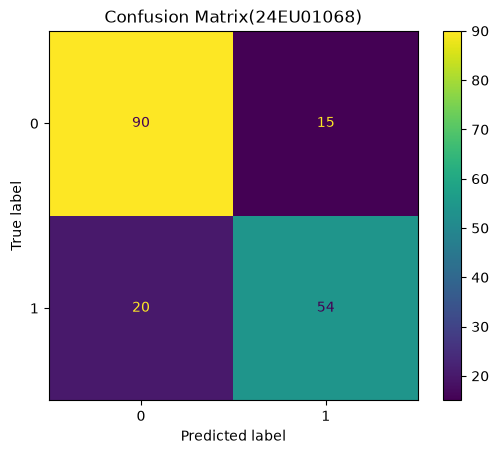

In [16]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix(24EU01068)")
plt.show()

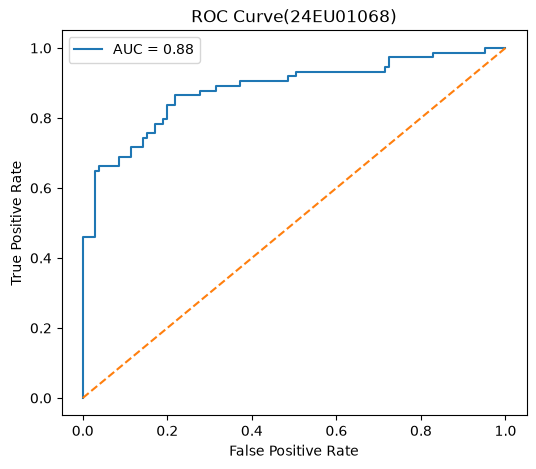

In [17]:
y_prob = lr_model.predict_proba(X_test)[:,1]
fpr,tpr,threshold = roc_curve(y_test,y_prob)
roc_auc = auc(fpr,tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr,tpr,label='AUC = %0.2f'%roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve(24EU01068)")
plt.legend()
plt.show()

In [18]:
scores = cross_val_score(lr_model,X,y,cv=5)
print(scores)
print("Average Accuracy :",scores.mean())

[0.77094972 0.78651685 0.78089888 0.76404494 0.82022472]
Average Accuracy : 0.7845270227857636


# Linear Discriminant Analysis (LDA)

Linear Discriminant Analysis (LDA) is a supervised classification algorithm that finds linear combinations of features to separate different classes. It aims to maximize the distance between classes while minimizing the variation within each class, making it useful for classification tasks.

In [19]:
lda_model = LinearDiscriminantAnalysis()
lda_model.fit(X_train,y_train)
lda_preds = lda_model.predict(X_test)

In [20]:
print("Accuracy :",accuracy_score(y_test,lda_preds))

Accuracy : 0.7932960893854749


In [21]:
print(classification_report(y_test,lda_preds))

              precision    recall  f1-score   support

           0       0.81      0.85      0.83       105
           1       0.77      0.72      0.74        74

    accuracy                           0.79       179
   macro avg       0.79      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



In [22]:
cm = confusion_matrix(y_test,lda_preds)
print(cm)

[[89 16]
 [21 53]]


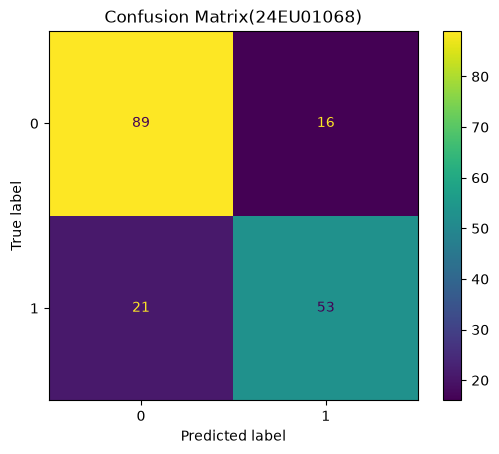

In [23]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix(24EU01068)")
plt.show()

In [24]:
scores = cross_val_score(lda_model,X,y,cv=5)
print(scores)
print("Average Accuracy :",scores.mean())

[0.79329609 0.80337079 0.78089888 0.75842697 0.81460674]
Average Accuracy : 0.7901198920343984


# k-Nearest Neighbors (k-NN)

k-Nearest Neighbors (k-NN) is a supervised learning algorithm that classifies a data point based on the majority class among its k nearest neighbors. It is a simple, non-parametric algorithm that works well for both binary and multi-class classification problems.

In [25]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train,y_train)
knn_preds = knn_model.predict(X_test)

In [26]:
print("Accuracy :",accuracy_score(y_test,knn_preds))

Accuracy : 0.7988826815642458


In [27]:
print(classification_report(y_test,knn_preds))

              precision    recall  f1-score   support

           0       0.82      0.85      0.83       105
           1       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



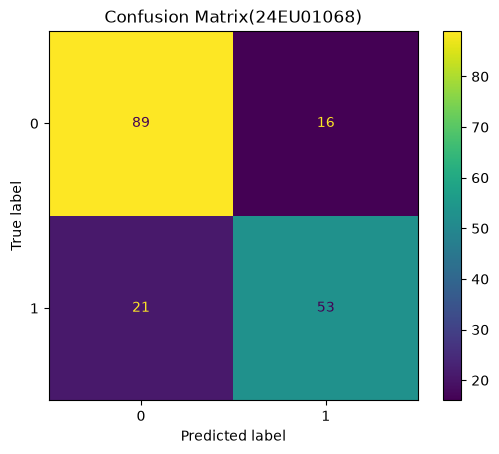

In [28]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix(24EU01068)")
plt.show()

In [29]:
scores = cross_val_score(knn_model,X,y,cv=5)
print(scores)
print("Average Accuracy :",scores.mean())

[0.79888268 0.76966292 0.8258427  0.81460674 0.81460674]
Average Accuracy : 0.8047203565375682
